# [기초-실습] 통계 101×데이터 분석: (7장) 싱관과 회귀

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비

### 1단계 · 한글 폰트 설치

- 그래프에 한글이 깨지지 않도록 나눔 폰트를 설치합니다.

- 실행 후 **[런타임] - [세션 다시 시작]**을 한 번 눌러야 폰트가 적용됩니다.

In [ ]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!pip install statsmodels
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

### 2단계 · 라이브러리 불러오기

- 이번 실습에서 쓰는 도구입니다. **한 번만 실행**해 두면 끝까지 사용합니다.

- `smf`는 회귀식을 `'y ~ x'` 형태로 쓰는 모듈, `het_breuschpagan`은 등분산 검정 함수입니다.

In [1]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

## 문제 1 · 펭귄의 부리는 길수록 두꺼울까?

`난이도 하` · `예상 15분`

**📖 상황**

- 남극 팔머 기지에서 측정한 펭귄 344마리의 신체 데이터(`penguins`)를 사용합니다.

- 부리 길이(`bill_length_mm`)와 부리 두께(`bill_depth_mm`)가 함께 어떻게 움직이는지 봅니다.

- 그런데 이 데이터에는 **세 종(Adelie·Chinstrap·Gentoo)이 섞여 있습니다.**
  전체를 뭉쳐서 볼 때와 집단을 나눠서 볼 때 **결론이 정반대로 뒤집히는 일**이 실제로 일어납니다.

**🎯 이 문제로 배우는 것**

- 상관계수를 계산하기 **전에** 산점도를 먼저 그려야 하는 이유를, 숫자로 직접 확인합니다.

In [2]:
# 문제 1 · 데이터 준비 — 실행만 하세요
penguins = sns.load_dataset('penguins')

print("데이터 크기:", penguins.shape)
print("\n종별 개체 수:")
print(penguins['species'].value_counts())
print("\n결측치 개수:")
print(penguins.isna().sum())

penguins.head()

데이터 크기: (344, 7)

종별 개체 수:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

결측치 개수:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Q1 · 산점도로 두 변수의 관계를 그려 봅시다

- 가로축 `bill_length_mm`, 세로축 `bill_depth_mm`로 산점도를 그리세요.

- 그래프 제목과 축 라벨을 한글로 알아보기 쉽게 설정하세요.

- `💡 힌트` `sns.scatterplot(data=..., x=..., y=...)` / `plt.title()`, `plt.xlabel()`, `plt.ylabel()`

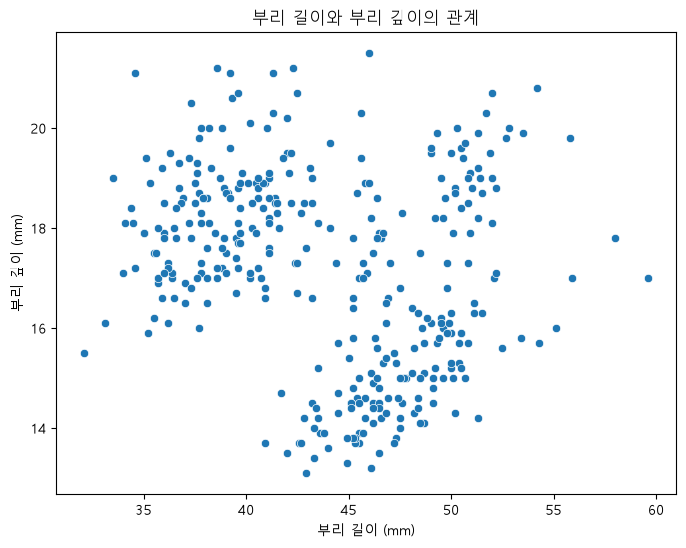

In [37]:
# 문제 1 · Q1
# 여기에 코드를 작성해주세요.
import seaborn as sns
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows 환경)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 산점도 그리기
plt.figure(figsize=(8, 6))
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm')

plt.title('부리 길이와 부리 깊이의 관계')
plt.xlabel('부리 길이 (mm)')
plt.ylabel('부리 깊이 (mm)')

plt.show()

### Q2 · 종별로 색을 나눠 같은 그림을 다시 그려 봅시다

- Q1과 똑같은 산점도에 펭귄의 종(`species`)별로 점의 색을 다르게 칠하세요.

- Q1의 그림과 나란히 놓고 무엇이 달라 보이는지 관찰하세요.

- `💡 힌트` `sns.scatterplot()`에 `hue` 인수를 추가해 보세요.

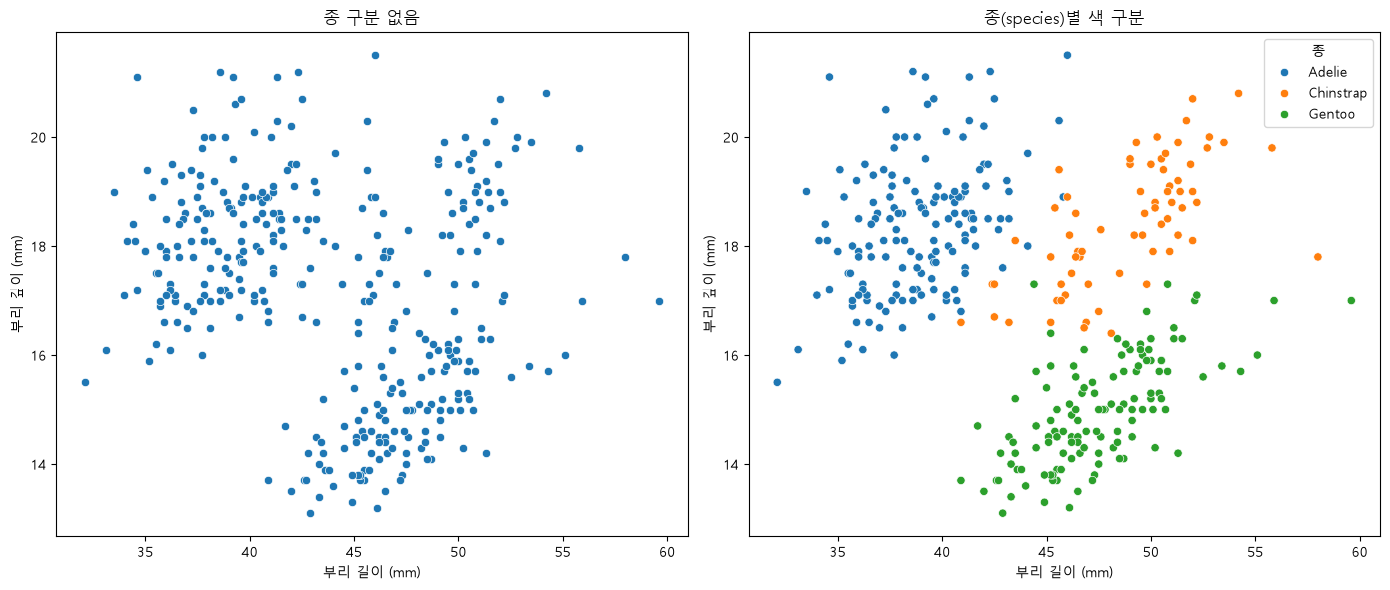

In [4]:
# 문제 1 · Q2
# 여기에 코드를 작성해주세요.
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Q1: 종 구분 없음
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', ax=axes[0])
axes[0].set_title('종 구분 없음')
axes[0].set_xlabel('부리 길이 (mm)')
axes[0].set_ylabel('부리 깊이 (mm)')

# Q2: 종별 색 구분
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', hue='species', ax=axes[1])
axes[1].set_title('종(species)별 색 구분')
axes[1].set_xlabel('부리 길이 (mm)')
axes[1].set_ylabel('부리 깊이 (mm)')
axes[1].legend(title='종')

plt.tight_layout()
plt.show()

### Q3 · 상관계수를 '전체'와 '종별'로 각각 구해 비교해 봅시다

- 두 변수의 상관계수를 **전체 데이터**에 대해 계산하세요.

- 같은 상관계수를 **종별로 나누어** 계산하세요.

- 두 결과의 **부호**를 비교하세요.

- `💡 힌트` 전체는 `df[['A','B']].dropna().corr()`,
  종별은 `df.groupby('species')[['A','B']].corr()`를 활용해 보세요.

In [28]:
# 문제 1 · Q3
# 여기에 코드를 작성해주세요.
cols = ['bill_length_mm', 'bill_depth_mm']

# 1) 전체 데이터에 대한 상관계수
overall_corr = penguins[cols].dropna().corr()

# 2) 종별 상관계수
species_corr = penguins.groupby('species')[cols].corr()

print("1) 전체 데이터 상관계수")
print(overall_corr)
print()
print("2) 종별 상관계수")
print(species_corr)

1) 전체 데이터 상관계수
                bill_length_mm  bill_depth_mm
bill_length_mm        1.000000      -0.235053
bill_depth_mm        -0.235053       1.000000

2) 종별 상관계수
                          bill_length_mm  bill_depth_mm
species                                                
Adelie    bill_length_mm        1.000000       0.391492
          bill_depth_mm         0.391492       1.000000
Chinstrap bill_length_mm        1.000000       0.653536
          bill_depth_mm         0.653536       1.000000
Gentoo    bill_length_mm        1.000000       0.643384
          bill_depth_mm         0.643384       1.000000


### 💬 정리 · 결과를 말로 설명해 보기

- Q1의 산점도에서 두 변수는 어떤 방향의 관계로 보였나요? Q3의 전체 상관계수와 부호가 일치하나요?

- Q3의 종별 상관계수는 전체와 부호가 같나요, 다른가요?

- **같은 데이터인데 전체와 집단별 결론이 정반대로 나온 이유**를 설명해 보세요. 무엇이 이 착시를 만들고 있나요?

- 만약 이 데이터에 '종' 정보가 없었다면 우리는 어떤 잘못된 결론을 내렸을까요?

 💡 생각의 갈피

- 부호가 뒤집히는 열쇠는 **종마다 부리의 '기본 크기'가 다르다**는 데 있습니다. 종별 평균이 어디에 놓여 있는지를 Q2의 그림에서 확인해 보세요.

- "전체를 보면 음, 나누면 양"은 두 변수 사이에 **숨은 집단 변수**가 끼어 있을 때 나타납니다. 이 현상에는 이름이 붙어 있고, 다음 시간 인과추론에서 다시 만납니다.

- 결론의 형태를 이렇게 나눠 써 보면 정확해집니다 — "종을 무시하면 ○○, 종을 고려하면 ○○".



# 문제 1 · 정리
# 여기에 의견을 작성해주세요.

- Q1의 산점도에서 두 변수는 어떤 방향의 관계로 보였나요? Q3의 전체 상관계수와 부호가 일치하나요?
Q1의 산점도(종 구분 없음)에서는 점들이 오른쪽 아래로 향하는 흐름처럼 보였습니다. 즉, 부리 길이가 길어질수록 부리 깊이는 오히려 얕아지는 것 같은 음의 방향 인상을 주었습니다. 실제로 Q3에서 계산한 전체 상관계수도 r = -0.235로, 산점도에서 받은 인상과 부호가 정확히 일치합니다.

- Q3의 종별 상관계수는 전체와 부호가 같나요, 다른가요?
완전히 다릅니다. 종별로 나누어 계산하면 Adelie(+0.391), Chinstrap(+0.654), Gentoo(+0.643) 세 종 모두 양(+)의 상관관계를 보입니다. 전체는 음(-), 종별은 모두 양(+)으로 부호가 정반대로 뒤집혔습니다.

- **같은 데이터인데 전체와 집단별 결론이 정반대로 나온 이유**를 설명해 보세요. 무엇이 이 착시를 만들고 있나요?
핵심은 **"종마다 부리의 기본 크기(baseline)가 다르다"**는 데 있습니다.

각 종 내부에서는 개체마다 "부리가 길면 깊이도 함께 깊어지는" 자연스러운 양의 관계가 실제로 존재합니다. (부리가 전체적으로 큰 개체는 길이도, 깊이도 함께 큰 경향)
하지만 종을 하나로 합쳐서 보면, Gentoo 종 자체가 다른 두 종보다 부리는 상대적으로 길지만 얕은(납작한) 독특한 체형을 갖고 있어서, 세 종의 "무리(cluster)"가 산점도 상에서 서로 다른 위치에 놓이게 되고 음의 상관관계처럼 보인다.
그 결과, 종이라는 **숨은 집단 변수(confounding variable)**가 만들어내는 "무리 간의 위치 차이"가, 각 무리 내부의 진짜 양의 관계를 가려버리고 오히려 정반대 방향의 착시를 만들어냅니다.

- 만약 이 데이터에 '종' 정보가 없었다면 우리는 어떤 잘못된 결론을 내렸을까요?
종 정보 없이 전체 342마리 펭귄을 하나의 집단으로만 분석했다면, "펭귄은 부리가 길수록 오히려 부리 깊이가 얕아지는 경향이 있다"는 사실과 반대되는 결론을 내렸을 것입니다. 실제로는 정반대로, 같은 종 안에서는 부리가 길수록 깊이도 함께 깊어지는 것이 생물학적으로 훨씬 더 자연스러운 관계인데도 말입니다.

## 문제 2 · 날개가 길면 몸무게도 무거울까? — 관계를 숫자로

`난이도 하` · `예상 20분`

**📖 상황**

- 문제 1에서 "숫자 전에 그림"을 배웠습니다. 이제 관계를 **숫자 하나**로 요약해 봅니다.

- 이번에는 **날개 길이(`flipper_length_mm`)와 몸무게(`body_mass_g`)**를 봅니다.
  이 두 변수는 **문제 5까지 계속 사용**하며, 상관 → 회귀 → 검정 → 진단으로 이어집니다.

- **피어슨 상관계수(r)**는 관계의 방향(부호)과 강도(절대값)를 −1~+1로 나타냅니다.
  다만 피어슨은 **두 변수가 정규분포라는 전제**에 기대는 모수적 방법입니다.

**🎯 이 문제로 배우는 것**

- 정규성 점검 → 피어슨(r과 p-값) → 스피어만 비교의 순서로, **강의에서 배운 절차 그대로** 상관을 구합니다.

결측치 제거 전: 344 행
결측치 제거 후: 342 행


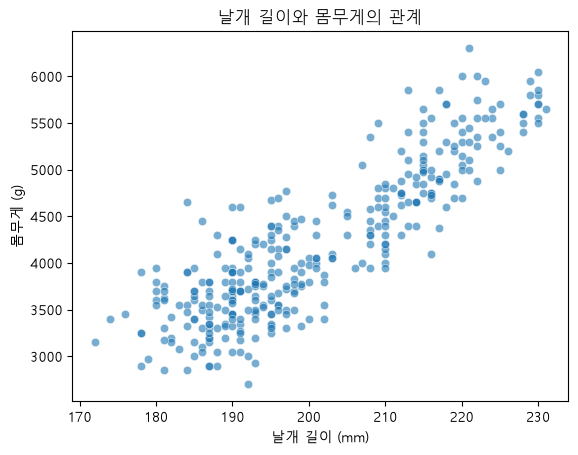

In [7]:
# 문제 2 · 데이터 준비 — 실행만 하세요
df_corr = penguins[['flipper_length_mm', 'body_mass_g']].dropna()

print("결측치 제거 전:", len(penguins), "행")
print("결측치 제거 후:", len(df_corr), "행")

# 두 변수의 관계를 그림으로 먼저 확인 (문제 1의 교훈!)
sns.scatterplot(data=df_corr, x='flipper_length_mm', y='body_mass_g', alpha=0.6)
plt.title("날개 길이와 몸무게의 관계")
plt.xlabel("날개 길이 (mm)")
plt.ylabel("몸무게 (g)")
plt.show()

### Q1 · 피어슨의 전제인 정규성을 점검해 봅시다

- `flipper_length_mm`과 `body_mass_g` **각각**에 대해 정규성 검정(Shapiro-Wilk)을 수행하세요.

- 유의수준 0.05를 기준으로 '정규성을 기각하는지'까지 함께 출력하세요.

- `💡 힌트` `stats.shapiro(데이터)`는 통계량과 p-값을 함께 돌려줍니다.

In [8]:
# 문제 2 · Q1
# 여기에 코드를 작성해주세요.
from scipy import stats

vars_to_test = ['flipper_length_mm', 'body_mass_g']
alpha = 0.05

for col in vars_to_test:
    data = penguins[col].dropna()
    stat, p = stats.shapiro(data)
    reject = "기각 (정규성 X)" if p < alpha else "기각 못함 (정규성 O)"
    print(f"[{col}]  W = {stat:.4f}, p = {p:.6f} → {reject}")

[flipper_length_mm]  W = 0.9515, p = 0.000000 → 기각 (정규성 X)
[body_mass_g]  W = 0.9592, p = 0.000000 → 기각 (정규성 X)


### Q2 · 피어슨 상관계수와 p-값을 함께 구해 봅시다

- 상관계수만이 아니라 **p-값도 함께** 구하세요. 상관계수도 가설검정의 대상입니다.

- 결과는 반드시 `r`, `p_value`라는 이름으로 저장하세요. **문제 3·4에서 이어서 사용합니다.**

- `💡 힌트` `r, p_value = stats.pearsonr(x, y)` — 귀무가설은 "모집단의 상관계수가 0이다"입니다.

In [9]:
# 문제 2 · Q2
# 여기에 코드를 작성해주세요.
from scipy import stats

# 결측치 제거 (두 변수 모두 값이 있는 행만 사용)
df = penguins[['flipper_length_mm', 'body_mass_g']].dropna()

x = df['flipper_length_mm']
y = df['body_mass_g']

r, p_value = stats.pearsonr(x, y)

print(f"r = {r:.4f}")
print(f"p_value = {p_value:.4e}")

r = 0.8712
p_value = 4.3707e-107


### Q3 · 스피어만 상관계수를 구해 피어슨과 비교해 봅시다

- 스피어만 상관계수(ρ)를 구하세요.

- Q2의 피어슨 값과 **나란히 출력**해 두 값의 차이를 눈으로 확인하세요.

- `💡 힌트` `stats.spearmanr(x, y)`

In [11]:
# 문제 2 · Q3
# 여기에 코드를 작성해주세요.
# 스피어만 상관계수
rho, p_spearman = stats.spearmanr(x, y)

print(f"피어슨 (r)   = {r:.4f}   (p = {p_value:.4e})")
print(f"스피어만 (ρ) = {rho:.4f}   (p = {p_spearman:.4e})")

피어슨 (r)   = 0.8712   (p = 4.3707e-107)
스피어만 (ρ) = 0.8400   (p = 2.7632e-92)


### Q4 · 세 결과를 종합해 관계를 문장으로 정리해 봅시다

- Q1~Q3의 결과를 근거로, 오른쪽 빈칸을 채워 관계를 정리하세요.

- 숫자만 적지 말고 **그 숫자가 뜻하는 바**를 함께 쓰세요.

문제 2 · Q4
- 정규성 검정 결과 (피어슨의 전제가 지켜졌나요?):  
두 변수 모두 Shapiro-Wilk 검정에서 p-value가 0.05보다 훨씬 작아 귀무가설이 기각되었습니다 (정규분포를 따른다고 볼 수 없음).  
<br/>
- 피어슨 r 값과 p-값:  
r = 0.8712, p-value ≈ 4.37×10⁻¹⁰⁷. r 값은 두 변수 사이에 매우 강한 양의 선형 관계가 있음을 뜻하고, p-value는 "실제로는 관계가 전혀 없다(r=0)"는 가정 하에 지금과 같은 결과가 우연히 나올 확률이 사실상 0이라는 뜻입니다. 즉 이 강한 관계는 우연이 아니라 통계적으로 유의미하다는 것을 의미합니다.  
<br/>
- 스피어만 ρ 값:  
ρ = 0.8400. 원래 값이 아니라 순위(rank)로 변환해 계산한 값으로, 정규성 가정 없이도 두 변수 사이에 강한 단조(monotonic) 양의 관계가 있음을 보여줍니다. 피어슨 r(0.8712)과 거의 차이가 없다는 것은, 두 변수의 관계가 순위로 봐도 원래 값으로 봐도 결론이 달라지지 않을 만큼 뚜렷하고 안정적인 선형·단조 관계라는 뜻입니다.  
<br/>
- 부호(+/-)가 뜻하는 관계의 방향:  
r과 ρ 모두 **부호가 (+)**입니다. 이는 날개 길이(flipper_length_mm)가 길어질수록 몸무게(body_mass_g)도 함께 증가하는 방향의 관계임을 뜻합니다. 즉 한 변수가 커지면 다른 변수도 커지는 정비례 관계입니다.  
<br/>
- 절대값의 크기가 뜻하는 관계의 강도:  
r| = 0.87, |ρ| = 0.84로 1에 매우 가까운 값입니다. 절대값이 1에 가까울수록 두 변수가 거의 하나의 직선(또는 단조 곡선)을 따라 함께 움직인다는 뜻이므로, 이는 "약한 관계"나 "중간 정도 관계"가 아니라 매우 강한 관계임을 의미합니다. 산점도로 그려보면 점들이 넓게 흩어져 있지 않고 뚜렷한 하나의 띠(band) 형태로 몰려 있을 것으로 예상할 수 있습니다.

### 💬 정리 · 결과를 말로 설명해 보기

- Q1에서 정규성이 기각되었습니다. 그렇다면 피어슨 상관계수를 쓰면 안 되는 걸까요? Q2와 Q3의 값을 비교해서 판단해 보세요.

- 피어슨과 스피어만이 비슷하게 나왔다는 것은 무엇을 뜻할까요? 만약 두 값이 크게 달랐다면 어떤 상황을 의심해야 할까요?

- Q2의 p-값은 무엇에 대한 검정인가요? "상관계수가 크다"와 "상관계수가 유의하다"는 같은 말인가요?

- '날개가 길어지는 것이 몸무게를 무겁게 만드는 **원인**이다'라고 결론 내릴 수 있을까요? **교란변수 / 역인과 / 우연** 세 가지로 나누어 설명해 보세요.

(클릭) 💡 생각의 갈피

- 정규성이 깨졌을 때 확인할 것은 "쓰면 안 되나"가 아니라 **"결론이 바뀌는가"**입니다. 두 계수가 거의 같다면 전제 위배의 영향이 작다는 뜻이고, 크게 다르면 이상치나 비선형을 의심합니다.

- p-값은 관계의 **크기**가 아니라 **존재**에 대한 답입니다. 표본이 커지면 아주 작은 상관도 유의해집니다 — 두 질문을 분리해서 답해 보세요.

- 인과를 부정하는 세 갈래를 이 데이터에 대입해 보세요. 교란변수 후보는 문제 1에서 이미 만났습니다.


# 문제 2 · 정리
# 여기에 의견을 작성해주세요.
- Q1에서 정규성이 기각되었습니다. 그렇다면 피어슨 상관계수를 쓰면 안 되는 걸까요? Q2와 Q3의 값을 비교해서 판단해 보세요.  
Q2(피어슨 r = 0.8712)와 Q3(스피어만 ρ = 0.8400)의 값을 비교해보면, 정규성 가정 없이 계산한 스피어만도 피어슨과 거의 같은 결론(매우 강한 양의 관계)을 보여줍니다. 두 값의 차이는 0.03에 불과합니다. 이는 정규성 위배가 결론을 뒤집을 만큼 심각하지 않다는 것을 뜻합니다. 즉, 이 경우에는 피어슨을 사용해도 실질적으로 문제가 없다고 판단할 수 있습니다.  

- 피어슨과 스피어만이 비슷하게 나왔다는 것은 무엇을 뜻할까요? 만약 두 값이 크게 달랐다면 어떤 상황을 의심해야 할까요?
두 계수가 비슷하다는 것은 두 변수의 관계가 이상치나 극단적인 비선형성 없이, 순위로 봐도 원래 값으로 봐도 동일하게 뚜렷한 선형 관계

만약 두 값이 크게 달랐다면 다음과 같은 상황을 의심해야 합니다.

    - 이상치(outlier)의 존재: 피어슨은 원래 값을 그대로 쓰기 때문에 극단값 하나에도 크게 흔들리지만, 스피어만은 순위로 바꾸므로 극단값의 영향을 덜 받습니다. 그래서 피어슨과 스피어만의 차이가 크다면 이상치가 상관계수를 왜곡시키고 있다는 신호일 수 있습니다.
    - 비선형(하지만 단조적인) 관계: 예를 들어 관계가 로그 곡선이나 지수 곡선 형태라면, 직선 관계만 잡아내는 피어슨은 그 강도를 과소평가하지만, 순위 기반의 스피어만은 단조성만 있으면 여전히 높은 값을 보여줍니다.

- Q2의 p-값은 무엇에 대한 검정인가요? "상관계수가 크다"와 "상관계수가 유의하다"는 같은 말인가요?
Q2의 p-값은 **귀무가설 H0: "모집단의 상관계수는 0이다(관계가 없다)"**에 대한 검정 결과입니다. p ≈ 4.37×10⁻¹⁰⁷이라는 것은, 실제로 관계가 전혀 없다고 가정했을 때 지금 관찰한 것과 같은 결과가 우연히 나올 확률이 사실상 0이라는 뜻이며, 따라서 "관계가 존재한다"는 것을 통계적으로 유의미하게 뒷받침합니다.

"크다"와 "유의하다"는 결코 같은 말이 아닙니다. **"유의하다(significant)"**는 그 관계가 우연이 아니라 실제로 존재할 가능성이 높다는 뜻이지, 그 관계가 **강하다(크다)**는 뜻이 아닙니다.

- '날개가 길어지는 것이 몸무게를 무겁게 만드는 **원인**이다'라고 결론 내릴 수 있을까요? **교란변수 / 역인과 / 우연** 세 가지로 나누어 설명해 보세요.
아니요, 상관관계만으로는 인과관계를 증명할 수 없습니다. 이 결론을 부정하는 세 갈래로 나누어 보면:

① 교란변수 (Confounding variable)
날개 길이와 몸무게 둘 다에 동시에 영향을 미치는 제3의 변수가 있을 가능성이 큽니다. 가장 유력한 후보는 바로 **종(species)**과 성별(sex), 그리고 그 둘의 근본 원인인 **유전적 체구(전반적인 크기, body size)**입니다. Gentoo 종처럼 원래 체구 자체가 큰 종은 날개도 길고 몸무게도 무겁습니다. 즉, "날개 길이 → 몸무게"가 아니라 "(종/전체적인 체구) → 날개 길이"이면서 동시에 "(종/전체적인 체구) → 몸무게"인 구조일 수 있습니다. 문제 2~3에서 다뤘던 심슨의 역설도 바로 이 교란변수(종) 때문에 생긴 현상이었습니다.

② 역인과 (Reverse causation)
이 데이터에서는 생물학적으로 가능성이 낮지만, 논리적으로는 "몸무게가 무거운 개체가 날개도 더 길게 자란다"는 반대 방향의 인과관계일 가능성도 완전히 배제할 수는 없습니다. 상관계수 자체는 방향을 알려주지 않으므로, 어느 쪽이 원인이고 어느 쪽이 결과인지는 상관분석만으로는 구분할 수 없습니다.

③ 우연 (Coincidence)
다만 이번 경우는 p-value가 사실상 0에 가깝고 표본도 342로 충분히 크기 때문에, "단순히 우연히 이런 패턴이 나왔다"고 볼 가능성은 매우 낮습니다. 우연이라는 설명은 여기서는 설득력이 약합니다.

## 문제 3 · 그 관계를 하나의 식으로 만들 수 있을까?

`난이도 중` · `예상 25분`

**📖 상황**

- 상관계수는 "관계가 얼마나 **강한가**"만 알려주고, "날개가 1mm 길면 몸무게가 **몇 g** 늘어나는가"는
  말해주지 않습니다. 그 답을 주는 것이 **선형회귀(Linear Regression)**입니다.

- 흩어진 점들을 가장 잘 가로지르는 직선 `y = a + bx`를 찾아 관계를 하나의 **식**으로 표현합니다.
  `a`(절편)는 x가 0일 때의 예측값, `b`(기울기)는 **x가 1 늘 때 y가 평균적으로 변하는 양**입니다.

- 그런데 상관과 회귀는 **서로 남이 아닙니다.** 문제 2에서 구한 `r`과
  이번에 구할 기울기·결정계수 사이에는 정확한 관계식이 성립합니다.

**🎯 이 문제로 배우는 것**

- 회귀식을 적합·해석하고, **상관과 회귀가 한 뿌리임을 숫자로 확인**합니다.

In [12]:
# 문제 3 · 데이터 준비 — 실행만 하세요
penguins_cleaned = penguins.dropna(subset=['body_mass_g', 'flipper_length_mm'])

print("분석에 사용할 데이터:", len(penguins_cleaned), "행")
print("문제 2의 df_corr과 동일한가?:", len(penguins_cleaned) == len(df_corr))

분석에 사용할 데이터: 342 행
문제 2의 df_corr과 동일한가?: True


### Q1 · 단순회귀 모델을 적합해 봅시다

- **날개 길이(설명변수) → 몸무게(반응변수)** 회귀 모델을 적합하세요.

- 적합한 모델은 반드시 `model`이라는 이름으로 저장하세요. **문제 4·5에서 이어서 사용합니다.**

- `💡 힌트` `model = smf.ols(formula='body_mass_g ~ flipper_length_mm', data=...).fit()`

In [13]:
# 문제 3 · Q1
# 여기에 코드를 작성해주세요.
import statsmodels.formula.api as smf

model = smf.ols(formula='body_mass_g ~ flipper_length_mm', data=penguins_cleaned).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):          4.37e-107
Time:                        12:14:43   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5780.8314    305.81

### Q2 · 분석 결과표를 출력해 봅시다

- 적합한 모델의 요약 결과표를 출력하세요.

- `coef`, `P>|t|`, `R-squared` 열이 각각 어디에 있는지 눈으로 찾아 두세요. 다음 문제들에서 계속 씁니다.

- `💡 힌트` 모델 객체의 `.summary()` 메소드를 사용하세요.

In [14]:
# 문제 3 · Q2
# 여기에 코드를 작성해주세요.
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):          4.37e-107
Time:                        12:15:33   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5780.8314    305.81

### Q3 · 회귀식을 완성해 봅시다

- Q2의 결과표에서 **절편**과 **기울기**를 찾아 오른쪽 빈칸을 채우세요.

- 숫자를 옮겨 적은 뒤, 완성된 식을 한 줄로 써 보세요.

In [ ]:
# 문제 3 · Q3
# 절편(a) 값: -5780.8314
# 기울기(b) 값: 49.6856
# 완성된 회귀식 → 몸무게(g) = -5780.8314 + 49.6856 × 날개길이(mm)

### Q4 · 회귀식으로 예측해 봅시다

- 날개 길이가 평균보다 **10mm 더 긴** 펭귄은, 평균적인 펭귄보다 몸무게가 몇 g 더 무거울까요?

- 계산 결과를 단위(g)와 함께 출력하세요.

- `💡 힌트` 기울기 × 10

In [15]:
# 문제 3 · Q4
# 여기에 코드를 작성해주세요.
b = 49.6856
diff = b * 10
print(f"{diff:.1f}g")

496.9g


### Q5 · 상관과 회귀를 잇는 두 관계식을 확인해 봅시다

- 다음 두 식이 실제로 성립하는지 **숫자로** 확인하세요.
  - ① 기울기 = `r` × (y의 표준편차 / x의 표준편차)
  - ② 결정계수 `R²` = `r²` _(단순회귀에서만 성립)_

- 좌변과 우변을 **나란히 출력**해 두 값이 일치하는지 눈으로 확인하세요.

- `💡 힌트` 문제 2 Q2의 `r`을 사용합니다. 표준편차는 `.std(ddof=1)`, 모델의 R²는 `model.rsquared`입니다.

In [18]:
# 문제 3 · Q5
# 여기에 코드를 작성해주세요.
sd_x = x.std(ddof=1)
sd_y = y.std(ddof=1)

# ① 기울기 = r × (sd_y / sd_x)
b_from_r = r * (sd_y / sd_x)
print(f"좌변(b) = {b:.4f}, 우변(r×sd_y/sd_x) = {b_from_r:.4f}")

# ② R² = r²
print(f"좌변(R²) = {model.rsquared:.4f}, 우변(r²) = {r**2:.4f}")

좌변(b) = 49.6856, 우변(r×sd_y/sd_x) = 49.6856
좌변(R²) = 0.7590, 우변(r²) = 0.7590


### 💬 정리 · 결과를 말로 설명해 보기

- 기울기(b) 값을 "날개 길이가 ○○할 때 몸무게가 ○○한다"는 문장으로 풀어 써 보세요.

- 절편(a)이 음수로 나왔습니다. 이 숫자를 "날개 길이가 0mm인 펭귄의 몸무게"로 해석해도 될까요? 왜 그럴까요?

- Q5에서 `R² = r²`을 확인했습니다. 그렇다면 설명변수와 반응변수를 서로 바꿔 분석하면 **기울기**와 **R²**는 각각 같을까요, 다를까요?

- 상관계수 `r`은 단위 없는 −1~1 값이고, 기울기 `b`는 'mm당 g'이라는 단위를 가집니다. 회귀가 상관보다 더 알려주는 것은 무엇인가요?

(클릭) 💡 생각의 갈피

- 절편은 **데이터가 존재하는 범위 밖의 값**입니다. 날개 길이 0mm인 펭귄은 우리 데이터에 없습니다 — 회귀식은 관측 범위 안에서만 의미를 갖습니다.

- x와 y를 바꿨을 때를 생각할 때 기준은 **"r은 대칭인가, s_y/s_x는 대칭인가"**입니다. 두 관계식 ①②를 각각 대입해 보면 답이 갈립니다.

- "강도"와 "변화량"의 차이로 정리해 보세요. 보고서에 "1mm당 ○g"을 쓸 수 있는 쪽은 어느 것인가요?

문제 3 · 정리
여기에 의견을 작성해주세요.

- 기울기(b) 값을 "날개 길이가 ○○할 때 몸무게가 ○○한다"는 문장으로 풀어 써 보세요.  
"날개 길이가 1mm 길어질 때, 몸무게는 평균적으로 약 49.69g 늘어난다."

- 절편(a)이 음수로 나왔습니다. 이 숫자를 "날개 길이가 0mm인 펭귄의 몸무게"로 해석해도 될까요? 왜 그럴까요?
아니요, 해석할 수 없습니다.

절편은 수학적으로 회귀직선을 정의하는 데 필요한 값이지만, 그 자체로 실제 의미를 갖는 것은 회귀식이 관측된 데이터의 범위(대략 172mm ~ 231mm) 안에 있을 때뿐입니다.

- Q5에서 `R² = r²`을 확인했습니다. 그렇다면 설명변수와 반응변수를 서로 바꿔 분석하면 **기울기**와 **R²**는 각각 같을까요, 다를까요?  
기울기는 다르고, R²는 같습니다.

Q5에서 확인한 두 관계식에 각각 대입해서 판단해볼 수 있습니다.

① 기울기 = r × (sd_y / sd_x): 이 식에서 r은 x, y를 바꿔도 값이 같은 대칭적인 값(r_xy = r_yx)입니다. 하지만 sd_y / sd_x는 분자·분모가 뒤바뀌므로, x와 y를 서로 바꾸면 이 비율은 역수 관계도 아닌 완전히 다른 값이 됩니다. 따라서 기울기는 바뀝니다. (앞서 문제 1에서 다뤘던 내용과 정확히 일치합니다.)
② R² = r²: 이 식은 오직 r만으로 결정되는데, r 자체가 x·y에 대해 대칭이므로 r²도 당연히 대칭입니다. 따라서 x, y를 바꿔도 R²는 정확히 동일합니다.

즉, "관계가 얼마나 강한지(R²)"는 어느 쪽을 원인/결과로 놓든 변하지 않지만, "구체적으로 몇 단위 변하는지(기울기)"는 어느 변수를 기준으로 보느냐에 따라 달라집니다.

- 상관계수 `r`은 단위 없는 −1~1 값이고, 기울기 `b`는 'mm당 g'이라는 단위를 가집니다. 회귀가 상관보다 더 알려주는 것은 무엇인가요?
r은 "관계의 강도"를, b는 "관계의 구체적인 변화량(효과 크기)"을 알려줍니다.

r은 −1~1 사이의 단위 없는 숫자로, "이 관계가 얼마나 뚜렷한가(강한가/약한가)"만 말해줄 뿐, 실제로 한쪽이 변할 때 다른 쪽이 몇 g, 몇 cm 만큼 변하는지는 알려주지 않습니다.

반면 회귀의 기울기 b는 원래 변수의 단위(mm, g)를 그대로 가지고 있어서, **"날개 길이 1mm당 몸무게 49.69g"**처럼 실무 보고서나 실제 의사결정에 바로 쓸 수 있는 구체적인 정량적 예측치를 제공합니다.  

상관이 "관계가 있다/강하다"를 판단하는 도구라면, 회귀는 한 걸음 더 나아가 "그래서 얼마나(how much)"라는 질문에 답하는, 예측과 실무 적용이 가능한 형태로 관계를 바꿔주는 도구입니다.

## 문제 4 · 이 기울기, 우연이 아니라고 말할 수 있을까?

`난이도 중` · `예상 25분`

**📖 상황**

- 문제 3에서 기울기를 구했습니다. 그런데 이 값은 **표본 342마리에서 계산된 값**입니다.

- 만약 전체 펭귄 집단에서 두 변수가 실제로는 아무 관계가 없다면(**기울기 = 0**),
  우리가 얻은 기울기는 그저 **표본을 뽑는 과정에서 우연히 생긴 값**일 수도 있습니다.

- 이 의심에 답하는 것이 **회귀계수의 가설검정**이고, 결과표의 `P>|t|` 열이 판단 근거입니다.

**🎯 이 문제로 배우는 것**

- 강의에서 배운 **상관계수의 유의성 검정**과 회귀계수 검정이 **같은 검정**임을 확인하고,
  p-값이 항상 작게 나오는 것은 아니라는 사실을 **기각 실패 사례**로 직접 만납니다.

In [19]:
# 문제 4 · 데이터 준비 — 실행만 하세요
# 문제 3의 Q1을 먼저 완료해야 이 문제를 풀 수 있습니다.

print("분석 대상 데이터:", len(penguins_cleaned), "행 (문제 3과 동일)")
print("설명변수: flipper_length_mm  /  반응변수: body_mass_g")

분석 대상 데이터: 342 행 (문제 3과 동일)
설명변수: flipper_length_mm  /  반응변수: body_mass_g


### Q1 · 가설을 세워 봅시다

- 회귀계수(기울기)에 대한 귀무가설(H₀)과 대립가설(H₁)을 오른쪽 빈칸에 쓰세요.

- '기울기'가 무엇과 같은지/다른지를 명확히 적으세요.

In [ ]:
# 문제 4 · Q1
# H₀ (귀무가설): 모집단에서 날개 길이(flipper_length_mm)의 회귀계수(기울기, β)는 0과 같다. 
# → (즉, 날개 길이는 몸무게를 예측하는 데 실제로는 아무런 관계가 없다.)
# H₁ (대립가설): 모집단에서 날개 길이의 회귀계수(기울기, β)는 0이 아니다. 
# → (즉, 날개 길이는 몸무게와 실제로 관계가 있다.)

### Q2 · 기울기의 p-값을 찾아 봅시다

- `flipper_length_mm` 행에서 `P>|t|` 열의 값을 찾아 출력하세요.

- `💡 힌트` 결과표에서 눈으로 찾아도 되고, 모델 객체의 `.pvalues` 속성을 써도 됩니다.

In [22]:
# 문제 4 · Q2
# 여기에 코드를 작성해주세요.
p_val = model.pvalues['flipper_length_mm']
print(f"P>|t| (flipper_length_mm) = {p_val:.4e}")
print("4.3707 × 10⁻¹⁰⁷")

P>|t| (flipper_length_mm) = 4.3707e-107
4.3707 × 10⁻¹⁰⁷


### Q3 · 유의수준 0.05로 결론을 내려 봅시다

- p-값과 유의수준 `alpha = 0.05`를 비교해, **판정 결과를 문장으로 출력하는 코드**를 작성하세요.

- 숫자만 찍지 말고 "기각한다 / 기각하지 못한다"까지 출력되도록 만드세요.

In [23]:
# 문제 4 · Q3
# alpha = 0.05

# 여기에 코드를 작성해주세요.
p_val = model.pvalues['flipper_length_mm']
alpha = 0.05

if p_val < alpha:
    result = (f"p-값({p_val:.4e})이 유의수준({alpha})보다 작으므로, "
              f"귀무가설(H0: 기울기=0)을 기각한다. "
              f"→ 날개 길이와 몸무게 사이의 관계는 통계적으로 유의미하다.")
else:
    result = (f"p-값({p_val:.4e})이 유의수준({alpha})보다 크므로, "
              f"귀무가설(H0: 기울기=0)을 기각하지 못한다. "
              f"→ 통계적으로 유의미하다고 볼 수 없다.")

print(result)

p-값(4.3707e-107)이 유의수준(0.05)보다 작으므로, 귀무가설(H0: 기울기=0)을 기각한다. → 날개 길이와 몸무게 사이의 관계는 통계적으로 유의미하다.


### Q4 · 상관계수의 검정과 같은 검정인지 확인해 봅시다

- 강의에서 배운 공식으로 t-통계량을 **직접 계산**하세요.

  `t = r × √(n − 2) / √(1 − r²)`

- 이 값을 `model.tvalues['flipper_length_mm']`와 **나란히 출력**해 비교하세요.

- `💡 힌트` `n`은 표본 크기(`len(penguins_cleaned)`), `r`은 문제 2 Q2에서 구한 값입니다.

In [24]:
# 문제 4 · Q4
# 여기에 코드를 작성해주세요.
import numpy as np

r, _ = stats.pearsonr(x, y)
n = len(penguins_cleaned)

# 공식으로 직접 계산한 t
t_manual = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)

# statsmodels가 계산한 t
t_model = model.tvalues['flipper_length_mm']

print(f"직접 계산한 t (공식)        = {t_manual:.6f}")
print(f"model.tvalues (statsmodels) = {t_model:.6f}")

직접 계산한 t (공식)        = 32.722234
model.tvalues (statsmodels) = 32.722234


### Q5 · p-값이 크게 나오는 사례를 만나 봅시다

- **Adelie 종 수컷만** 골라, `bill_length_mm`으로 `body_mass_g`를 설명하는 회귀를 적합하세요.

- 기울기의 p-값을 유의수준 0.05와 비교하고, 표본 크기(n)와 `R²`도 함께 출력하세요.

- `💡 힌트` 먼저 필요한 열의 결측치를 제거한 뒤 조건으로 걸러 냅니다.
  `df[(df['species'] == 'Adelie') & (df['sex'] == 'Male')]`

In [25]:
# 문제 4 · Q5
# 여기에 코드를 작성해주세요.
df_filtered = penguins.dropna(subset=['bill_length_mm', 'body_mass_g', 'species', 'sex'])
adelie_male = df_filtered[(df_filtered['species'] == 'Adelie') & (df_filtered['sex'] == 'Male')]

model_adelie = smf.ols(formula='body_mass_g ~ bill_length_mm', data=adelie_male).fit()

n = len(adelie_male)
p_val = model_adelie.pvalues['bill_length_mm']
r_squared = model_adelie.rsquared

print(f"n = {n}, 기울기 = {model_adelie.params['bill_length_mm']:.4f}")
print(f"p-value = {p_val:.4f}, R² = {r_squared:.4f}")

n = 73, 기울기 = 33.5628
p-value = 0.0610, R² = 0.0486


### 💬 정리 · 결과를 말로 설명해 보기

- p-값이 작다는 것은 정확히 무엇이 작다는 뜻인가요? "귀무가설이 참일 확률"이라고 말해도 될까요?

- Q4에서 두 t값이 일치했습니다. 이것은 상관계수의 검정과 회귀계수의 검정이 **어떤 관계**임을 뜻하나요?

- Q5의 결과는 Q2와 어떻게 달랐나요? 같은 `penguins` 데이터인데 결론이 갈린 이유를 **표본 크기**와 **관계의 강도(R²)** 두 측면에서 설명해 보세요.

- Q5처럼 p-값이 0.05보다 조금 큰 경우, "두 변수는 관계가 없음이 증명되었다"고 말할 수 있을까요? 어떻게 말하는 것이 정확할까요?

(클릭) 💡 생각의 갈피

- p-값은 "H₀가 참이라고 **가정했을 때** 이런 결과가 나올 확률"입니다. 가정과 결론의 방향을 뒤집지 않도록 문장을 조심해서 써 보세요.

- Q4의 일치는 우연이 아닙니다. 단순회귀에서는 "두 변수가 무관하다"는 하나의 가설을 두 가지 방식으로 적었을 뿐입니다 — 그래서 t도 p도 같습니다.

- 기각 실패는 **"관계가 없다"가 아니라 "관계가 있다는 증거가 부족하다"**입니다. Q5의 n과 R²를 보면 왜 증거가 부족했는지 짐작할 수 있습니다.

# 문제 4 · 정리
# 여기에 의견을 작성해주세요.

### 💬 정리 · 결과를 말로 설명해 보기

- p-값이 작다는 것은 정확히 무엇이 작다는 뜻인가요? "귀무가설이 참일 확률"이라고 말해도 될까요?  
아니요, 그렇게 말하면 안 됩니다. 이는 p-value 해석에서 가장 흔히 생기는 오해입니다.  
p-값이 작다는 건 **"만약 두 변수 사이에 정말 아무 관계가 없다면(귀무가설이 맞다면), 우리가 지금 본 것 같은 결과(또는 더 극단적인 결과)가 우연히 나올 확률"**이 작다는 뜻입니다.
"귀무가설이 참일 확률"이라고 말하면 안 됩니다. 이건 아주 흔한 오해입니다.

- Q4에서 두 t값이 일치했습니다. 이것은 상관계수의 검정과 회귀계수의 검정이 **어떤 관계**임을 뜻하나요?
상관계수 검정과 회귀계수(기울기) 검정이 사실은 겉모습만 다른, 완전히 같은 검정이라는 뜻입니다.

- Q5의 결과는 Q2와 어떻게 달랐나요? 같은 `penguins` 데이터인데 결론이 갈린 이유를 **표본 크기**와 **관계의 강도(R²)** 두 측면에서 설명해 보세요.

같은 penguins 데이터인데도 결론이 완전히 갈렸습니다.

Q2 (전체 342마리, 날개 길이 vs 몸무게): p ≈ 0에 가까운 극도로 작은 값 → 매우 유의미
Q5 (Adelie 수컷 73마리만, 부리 길이 vs 몸무게): p = 0.061 → 유의미하다고 말할 수 없음

표본 크기 측면: 342마리에서 73마리로 확 줄었습니다. 표본이 작아지면, 실제로 관계가 있어도 그 증거가 우연한 변동에 묻히기 쉬워집니다. 같은 크기의 효과라도 데이터가 적으면 "우연이 아니다"라고 자신 있게 말하기가 어려워집니다.

관계의 강도(R²) 측면: Q2에서는 R² = 0.759로 몸무게 변동의 76%를 설명할 만큼 관계가 강했습니다. 하지만 Q5에서는 R² = 0.049로, 부리 길이가 몸무게 변동을 겨우 5%밖에 설명하지 못했습니다. 관계 자체가 약한 데다가, 그 종(Adelie)만 따로 떼어놓으니 앞서 문제 2~3에서 계속 봤던 "종이 다르면 크기 자체가 다르다"는 큰 변동 요인(교란변수)까지 사라져버려서, 남은 관계가 더욱 희미해진 것입니다.

- Q5처럼 p-값이 0.05보다 조금 큰 경우, "두 변수는 관계가 없음이 증명되었다"고 말할 수 있을까요? 어떻게 말하는 것이 정확할까요?

아니요, 그렇게 말하면 안 됩니다.

"기각하지 못했다"는 건 "관계가 없다는 것을 증명했다"는 뜻이 아니라, **"지금 가진 증거로는 관계가 있다고 자신 있게 말하기에 부족하다"**는 뜻일 뿐입니다

## 문제 5 · 미니 프로젝트 — 이 회귀모형, 믿고 보고해도 될까?

`난이도 상` · `예상 35분`

**📖 상황**

- 계수가 유의하다고 해서 분석이 끝난 것은 아닙니다. 보고서를 쓰기 전에 두 가지를 더 확인합니다.

- **① 얼마나 설명하는가 — 결정계수(R²)**
  반응변수 전체 변동 중 이 모델이 설명한 비율입니다.

- **② 전제가 지켜졌는가 — 잔차(Residual) 진단**
  잔차는 `실제값 − 예측값`입니다. 좋은 모델이라면 잔차가 **패턴 없이 0 주위에 고르게** 흩어져야 합니다.
  깔때기(부채꼴) 모양이면 **등분산성**이 깨졌다는 신호이고, 이때는 p-값과 신뢰구간을 그대로 믿기 어렵습니다.

**🎯 이 문제로 배우는 것**

- 우리 모형을 진단한 뒤, **일부러 문제가 있는 다른 모형과 나란히 놓고 비교**합니다.
  "통과한 잔차"만 보면 진단을 왜 하는지 알 수 없기 때문입니다.

In [29]:
# 문제 5 · 데이터 준비 — 실행만 하세요
# 문제 3의 Q1을 먼저 완료해야 이 문제를 풀 수 있습니다.

print("분석 대상 데이터:", len(penguins_cleaned), "행")
print("모형: body_mass_g ~ flipper_length_mm")

분석 대상 데이터: 342 행
모형: body_mass_g ~ flipper_length_mm


### Q1 · 결정계수로 설명력을 평가해 봅시다

- 모델의 `R-squared` 값을 출력하세요.

- 그 값이 뜻하는 바를 "몸무게 변동의 몇 %" 형태로 오른쪽 빈칸에 쓰세요.

- `💡 힌트` `model.rsquared`

In [30]:
# 문제 5 · Q1
# R-squared 값:
# 설명력 해석 (몸무게 변동의 몇 %를 설명하나요?):

# 여기에 코드를 작성해주세요.
print(f"R-squared = {model.rsquared:.4f}")

R-squared = 0.7590


### Q2 · 예측값과 잔차를 계산해 봅시다

- 모델의 **예측값**과 **잔차**를 각각 계산해 변수에 저장하세요.

- 잔차의 개수와 평균을 함께 출력해, 잔차가 0 주위에 모여 있는지 확인하세요.

- `💡 힌트` 예측값은 `.fittedvalues`, 잔차는 `.resid` 속성입니다.

In [31]:
# 문제 5 · Q2
# 여기에 코드를 작성해주세요.

fitted = model.fittedvalues   # 예측값
resid = model.resid           # 잔차 (실제값 - 예측값)

print(f"잔차 개수 = {len(resid)}")
print(f"잔차 평균 = {resid.mean():.10f}")

잔차 개수 = 342
잔차 평균 = 0.0000000000


### Q3 · 잔차 산점도를 그려 봅시다

- 가로축을 **예측값**, 세로축을 **잔차**로 하는 산점도를 그리세요.

- `y = 0` 기준선을 함께 표시하면 패턴을 보기 쉽습니다.

- `💡 힌트` `plt.scatter()` 와 `plt.axhline(0, color='red', linestyle='--')`

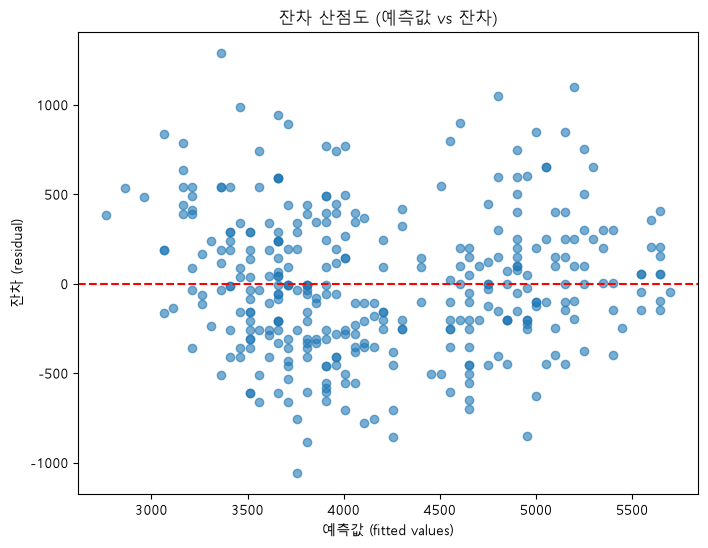

In [32]:
# 문제 5 · Q3
# 여기에 코드를 작성해주세요.
fitted = model.fittedvalues
resid = model.resid

plt.figure(figsize=(8, 6))
plt.scatter(fitted, resid, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('잔차 산점도 (예측값 vs 잔차)')
plt.xlabel('예측값 (fitted values)')
plt.ylabel('잔차 (residual)')
plt.show()

### Q4 · 등분산성을 숫자로 검정해 봅시다

- **브루쉬-페이건 검정**으로 등분산성을 확인하세요.

- H₀는 "등분산이다"입니다. p-값이 0.05보다 작으면 이분산을 의심합니다.

- 판정 결과를 문장으로 함께 출력하세요.

- `💡 힌트` `het_breuschpagan(잔차, model.model.exog)`는
  `(LM통계량, LM p-값, F통계량, F p-값)`을 돌려줍니다.

In [33]:
# 문제 5 · Q4
# 여기에 코드를 작성해주세요.
from statsmodels.stats.diagnostic import het_breuschpagan

lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(model.resid, model.model.exog)

alpha = 0.05
if lm_pvalue < alpha:
    print(f"p({lm_pvalue:.4f}) < {alpha} → 귀무가설(등분산) 기각. 이분산성 의심.")
else:
    print(f"p({lm_pvalue:.4f}) >= {alpha} → 귀무가설(등분산) 기각 못함. 등분산 가정 위배로 보기 어려움.")

p(0.1418) >= 0.05 → 귀무가설(등분산) 기각 못함. 등분산 가정 위배로 보기 어려움.


### Q5 · 문제가 있는 모형과 나란히 비교해 봅시다

- **비교군**으로 `body_mass_g ~ bill_length_mm` 모형을 적합해 `model_bill`로 저장하세요.

- 두 모형의 잔차 산점도를 **나란히** 그리세요.

- 두 모형의 브루쉬-페이건 p-값을 **함께 출력**해 비교하세요.

- `💡 힌트` `fig, ax = plt.subplots(1, 2, figsize=(12, 4))`로 두 그림을 옆으로 배치할 수 있습니다.

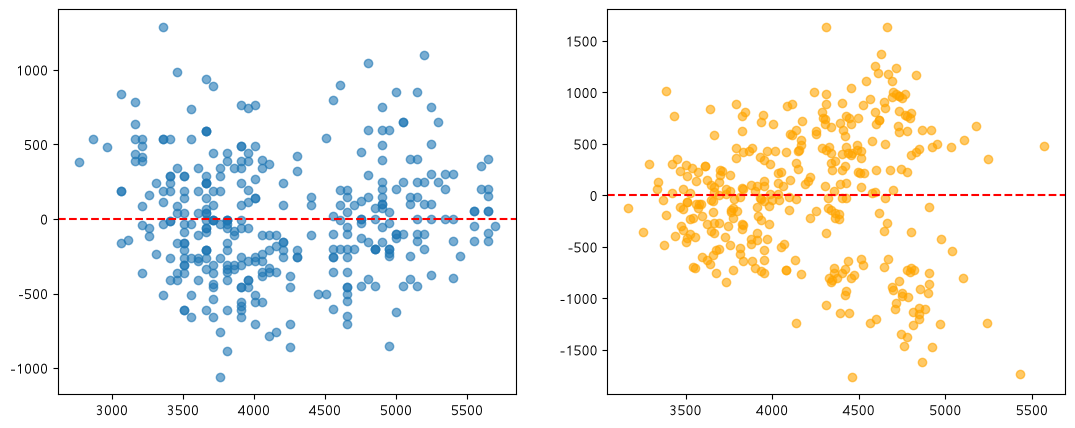

In [36]:
# 문제 5 · Q5
# 여기에 코드를 작성해주세요.

# bill_length_mm 결측치 제거
penguins_bill = penguins.dropna(subset=['body_mass_g', 'bill_length_mm'])

# 비교군 모델
model_bill = smf.ols(formula='body_mass_g ~ bill_length_mm', data=penguins_bill).fit()

lm_stat1, lm_p1, _, _ = het_breuschpagan(model.resid, model.model.exog)
lm_stat2, lm_p2, _, _ = het_breuschpagan(model_bill.resid, model_bill.model.exog)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(model.fittedvalues, model.resid, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[1].scatter(model_bill.fittedvalues, model_bill.resid, alpha=0.6, color='orange')
axes[1].axhline(0, color='red', linestyle='--')
plt.show()

### Q6 · 보고 문장으로 정리해 봅시다

- 지금까지의 결과를 종합해, 우리 회귀모형을 보고서에 어떻게 적을지 **한 문장**으로 쓰세요.

- **기울기 + 유의성 + 설명력 + 진단 결과**를 모두 담아 보세요.

문제 5 · Q6
- 보고 문장: 펭귄 342마리 데이터를 분석한 결과, 날개 길이(flipper_length_mm)는 몸무게(body_mass_g)를 유의수준 0.05에서 통계적으로 유의미하게 예측하였으며(b = 49.69g/mm, p < .001), 이 모델은 몸무게 변동의 75.9%를 설명하였고(R² = 0.759), 브루쉬-페이건 검정 결과(p = 0.142) 등분산성 가정을 위배하지 않아 회귀분석의 신뢰도를 확보하였다.

### 💬 정리 · 결과를 말로 설명해 보기

- Q3·Q4에서 우리 모형의 잔차는 어떤 상태였나요? 이 결과를 근거로 문제 3·4의 해석을 신뢰할 수 있을까요?

- Q5의 두 잔차 산점도는 어떻게 달랐나요? 비교군에서 관찰된 모양을 강의에서 배운 용어로 무엇이라 부르나요?

- 비교군처럼 등분산성이 깨졌을 때, **잘못된 것은 기울기 값 자체인가요, 아니면 그 값의 통계적 해석인가요?**

- R²가 1이 아니라는 것은 설명되지 않은 변동이 남아 있다는 뜻입니다. `penguins` 안에서 몸무게에 영향을 줄 만한데 우리 모델이 놓치고 있는 변수는 무엇일까요?

- 그 변수들을 모델에 함께 넣으려면 어떤 분석이 필요할까요?

(클릭) 💡 생각의 갈피

- 강의 7장은 이렇게 적었습니다 — _"파라미터 값이 잘못되었다는 뜻이 아니라, 이 값의 통계적 해석(유의성·신뢰구간)과 예측 결과를 신뢰할 수 없다는 의미"_. 세 번째 질문의 답이 여기 있습니다.

- 비교군의 잔차가 퍼지는 모양을 강의의 3케이스 그림(정규성 O·등분산 O / X·O / O·X)과 맞춰 보세요.

- 놓친 변수 후보는 문제 1의 그림에 이미 있습니다. 그 변수를 모델에 함께 넣는 분석의 이름은 다음 8장의 제목입니다.

# 문제 5 · 정리
# 여기에 의견을 작성해주세요.

- Q3·Q4에서 우리 모형의 잔차는 어떤 상태였나요? 이 결과를 근거로 문제 3·4의 해석을 신뢰할 수 있을까요?
Q3의 잔차 산점도(예측값 vs 잔차)에서는 점들이 y=0을 중심으로 뚜렷한 깔때기 모양이나 곡선 패턴 없이 고르게 흩어져 있었습니다. Q4의 브루쉬-페이건 검정에서도 p = 0.1418로, 등분산성이라는 귀무가설을 기각하지 못했습니다.

두 결과가 서로 어긋나지 않고 같은 결론(등분산 가정 유지)을 가리키고 있으므로, 문제 3(기울기 49.69g/mm)과 문제 4(p<.001로 유의미함)에서 얻은 해석은 신뢰할 수 있습니다. 등분산성이 지켜졌다는 것은, 그 유의성 검정이나 신뢰구간이 왜곡된 전제 위에서 계산된 것이 아니라는 뜻이기 때문입니다.

- Q5의 두 잔차 산점도는 어떻게 달랐나요? 비교군에서 관찰된 모양을 강의에서 배운 용어로 무엇이라 부르나요?
model(flipper_length)의 잔차는 예측값 전 구간에서 흩어짐 정도가 비교적 일정했던 반면, model_bill(bill_length)의 잔차는 예측값이 커질수록 점들의 세로 폭이 넓어지는 형태를 보였습니다.

이렇게 예측값(또는 설명변수)이 커질수록 잔차의 흩어짐(분산)이 함께 커지는 부채꼴/깔때기 모양을, 강의에서 배운 용어로 **이분산성(Heteroscedasticity)**이라고 부릅니다. 등분산성(Homoscedasticity) 가정이 깨진 상태입니다.

- 비교군처럼 등분산성이 깨졌을 때, **잘못된 것은 기울기 값 자체인가요, 아니면 그 값의 통계적 해석인가요?**
기울기 값 자체가 아니라, 그 값의 통계적 해석(유의성 검정, 신뢰구간)이 잘못될 수 있는 것입니다.

이분산성이 있어도 최소제곱법으로 구한 기울기(b) 추정치 자체는 여전히 편향되지 않은(unbiased) 값입니다. 문제가 생기는 곳은 **표준오차(standard error)**입니다. 이분산성이 있으면 표준오차 계산이 부정확해지고, 그 표준오차를 바탕으로 계산되는 t값, p-value, 신뢰구간이 실제보다 더 좁거나 넓게 나올 수 있습니다.

즉, "기울기가 49.69g/mm이다"라는 값 자체는 여전히 맞을 수 있지만, "이 값이 통계적으로 유의미하다(p<.001)"거나 "진짜 기울기는 46.7~52.7 사이에 있다(95% 신뢰구간)"는 해석의 신뢰도가 흔들리게 됩니다. 강의 7장에서 짚은 그대로, 파라미터 추정치의 문제가 아니라 그 추정치를 둘러싼 통계적 판단(유의성·신뢰구간·예측)의 문제입니다.

- R²가 1이 아니라는 것은 설명되지 않은 변동이 남아 있다는 뜻입니다. `penguins` 안에서 몸무게에 영향을 줄 만한데 우리 모델이 놓치고 있는 변수는 무엇일까요?
R²가 1이 아니라는 것은 무엇을 뜻하고, 놓친 변수는 무엇일까요?

R² = 0.759라는 것은 몸무게 변동의 나머지 24.1%가 날개 길이만으로는 설명되지 않는다는 뜻입니다. penguins 데이터 안에서 이 나머지를 설명해줄 만한 후보로는 다음이 있습니다.

species(종): 문제 1~2에서 이미 확인했던 변수입니다. Gentoo, Chinstrap, Adelie는 체구 자체가 다르고, 같은 날개 길이라도 종에 따라 몸무게 기준선이 다를 수 있습니다.
sex(성별): 일반적으로 수컷이 암컷보다 체구가 크고 무거운 경향이 있어, 몸무게 차이의 일부를 설명할 수 있습니다.
bill_length_mm, bill_depth_mm: 부리 크기도 개체의 전반적인 체구와 관련이 있을 수 있습니다.

- 그 변수들을 모델에 함께 넣으려면 어떤 분석이 필요할까요?
설명변수를 하나(flipper_length_mm)가 아니라 여러 개(species, sex 등)를 동시에 모델에 포함시켜서, 각 변수가 몸무게에 미치는 영향을 함께 추정하는 분석이 필요합니다. 이렇게 설명변수가 2개 이상인 회귀분석을 **다중회귀분석(Multiple Regression)**이라고 부르며, 말씀하신 대로 이것이 다음 장(8장)에서 다루게 될 주제입니다.

다중회귀를 쓰면, 예를 들어 "종과 성별을 통제(고정)한 상태에서, 날개 길이가 몸무게에 미치는 순수한 효과는 얼마인가"를 분리해서 볼 수 있게 되고, 이는 문제 2에서 다뤘던 심슨의 역설(숨은 교란변수 문제)을 통계적으로 바로잡는 실질적인 해결책이 되기도 합니다.